# RCT Data-Literacy — Immediate-Wave Analysis (v5-IMMEDIATE)

**Scope.** This notebook runs the pre-registered SAP (decisions D1–D11, `sections/SAP_04_07.tex`)
on the **immediate wave only** — the 72-hour delayed retest has not been collected yet. It is the
immediate-only sibling of `rct_data_literacy_analysis_4_FINAL.ipynb` (v4): every estimand that is
identified by immediate-wave data is estimated with the identical machinery; everything that needs
the delayed wave is explicitly marked *pending* rather than silently skipped.

**Statistical reductions used (each exact, not an approximation):**

1. **Primary accuracy (eq:primary-acc).** With one observation per participant the participant
   random intercept of the two-wave LMM is not separately identified, and the model evaluated at
   `wave_d = 0` reduces *exactly* to the covariate-adjusted ANCOVA
   $Y_i=\beta_0+\beta_1\mathrm{Soc}_i+\beta_2\mathrm{Unr}_i+\gamma_1\mathrm{VLAT}^c_i+\gamma_2\mathrm{AIUse}^c_i+\varepsilon_i$.
   Because D2 makes the immediate wave the reference level, $\beta_1,\beta_2$ here are **the same
   estimands** as in the full LMM — OLS with HC3 (small-sample robust) standard errors.
2. **Success time (eq:primary-st, D9-R2).** The arm×wave columns are structurally zero with one
   wave; the wave-stratified Cox reduces to a single-stratum Cox whose arm coefficients equal the
   immediate-wave log-HRs θ₁, θ₂. Fitted with `sap_estimators.fit_cox_st` (participant-clustered
   Lin–Wei sandwich), passing the reduced formula and `strata=None`.
3. **H4ₐ Bloom concentration** is defined on the immediate wave — runs unchanged (clustered GEE).
4. **H5ₐ/H5ₑ persistence, MICE, Lee bounds, dropout models** need wave 2 → *pending* (§6, §12).

**Interim caveat.** The export analysed here is the first live batch (n ≈ 28 of the planned
N = 200). The SAP pre-specifies **no interim look with α-spending**, so every "verdict" printed by
the confirmatory machinery below is a **provisional, monitoring-grade readout at the final α**,
not a confirmatory claim; the trial's confirmatory test happens once, on the full sample.
Estimates and CIs are exact for the data in hand.

**Shared estimators.** Fitting/contrast code is imported from `sap_estimators.py` (Monte-Carlo
validated; see D10) wherever the estimator is unchanged. Only the single-wave ANCOVA engine and
its gatekeeper wrapper are defined locally (mirroring `sap_estimators.gatekeeper` line-for-line,
with the OLS engine swapped in).

## 0. Setup and configuration
All thresholds below are the locked pre-registration values (speeding rule 1,000 ms — D10;
adoption-latency direct-adoption cutoff 5 s, to be locked from this pilot Δ distribution — D11;
NI margin Δ = 8.5 pp — D6). The answer key and the "I don't know" (IDK) letters were re-verified
2026-07-16 against `Code/thesis-rct/pcp_scoring.js` (`PCP_KEY` / `PCP_OMIT`) — byte-identical.

In [1]:
import json, re, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from lifelines import CoxPHFitter, KaplanMeierFitter, LogNormalAFTFitter
from lifelines.statistics import proportional_hazard_test

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*convergence.*", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*divide by zero.*")
warnings.filterwarnings("ignore", message=".*invalid value.*")

CONFIG = dict(
    DATA_PATH_CANDIDATES=[
        '/Users/brunokneffel/Downloads/RCT_DataLiteracy_DL_BK_July 17, 2026_15.46.csv',
    ],
    SEED=2026,
    PLANNED_N=200,                      # pre-registered target (D8): 66/arm
    # --- answer key: verified vs pcp_scoring.js PCP_KEY (2026-07-16) -------------
    ANSWER_KEY={
        "pcp_rem_fa_1": "A", "pcp_und_fa_1": "B", "pcp_ana_fa_1": "D", "pcp_eval_fa_10": "A",
        "pcp_rem_fa_2": "A", "pcp_und_fa_2": "B", "pcp_ana_fa_2": "B", "pcp_eval_fa_11": "A",
        "pcp_rem_sa_1": "A", "pcp_rem_sa_2": "A", "pcp_rem_sa_3": "C", "pcp_rem_sa_4": "B",
        "pcp_und_sa_1": "B", "pcp_und_sa_2": "B", "pcp_und_sa_3": "D", "pcp_und_sa_4": "B",
        "pcp_ana_sa_1": "B", "pcp_ana_sa_2": "B", "pcp_ana_sa_3": "A", "pcp_ana_sa_9": "C",
        "pcp_eval_sa_1": "A", "pcp_eval_sa_2": "A", "pcp_eval_sa_3": "A", "pcp_eval_sa_4": "A",
        "pcp_rem_sa_5": "B", "pcp_rem_sa_6": "C", "pcp_rem_sa_7": "B", "pcp_rem_sa_8": "A",
        "pcp_und_sa_5": "B", "pcp_und_sa_6": "A", "pcp_und_sa_7": "C", "pcp_und_sa_8": "B",
        "pcp_ana_sa_5": "B", "pcp_ana_sa_6": "A", "pcp_ana_sa_7": "B", "pcp_ana_sa_8": "A",
        "pcp_eval_sa_5": "D", "pcp_eval_sa_6": "A", "pcp_eval_sa_7": "A", "pcp_eval_sa_8": "A",
    },
    # --- IDK letters: verified vs pcp_scoring.js PCP_OMIT (2026-07-16) -----------
    IDK_OPTION={
        "pcp_rem_fa_1": "C", "pcp_und_fa_1": "D", "pcp_ana_fa_1": "E", "pcp_eval_fa_10": "E",
        "pcp_rem_fa_2": "C", "pcp_und_fa_2": "D", "pcp_ana_fa_2": "E", "pcp_eval_fa_11": "E",
        "pcp_rem_sa_1": "C", "pcp_rem_sa_2": "C", "pcp_rem_sa_3": "G", "pcp_rem_sa_4": "C",
        "pcp_und_sa_1": "D", "pcp_und_sa_2": "D", "pcp_und_sa_3": "F", "pcp_und_sa_4": "F",
        "pcp_ana_sa_1": "E", "pcp_ana_sa_2": "E", "pcp_ana_sa_3": "E", "pcp_ana_sa_9": "E",
        "pcp_eval_sa_1": "E", "pcp_eval_sa_2": "F", "pcp_eval_sa_3": "E", "pcp_eval_sa_4": "E",
        "pcp_rem_sa_5": "C", "pcp_rem_sa_6": "G", "pcp_rem_sa_7": "G", "pcp_rem_sa_8": "C",
        "pcp_und_sa_5": "D", "pcp_und_sa_6": "E", "pcp_und_sa_7": "E", "pcp_und_sa_8": "E",
        "pcp_ana_sa_5": "C", "pcp_ana_sa_6": "C", "pcp_ana_sa_7": "C", "pcp_ana_sa_8": "D",
        "pcp_eval_sa_5": "E", "pcp_eval_sa_6": "E", "pcp_eval_sa_7": "E", "pcp_eval_sa_8": "E",
    },
    # --- Mini-VLAT answer key (Pandey & Ottley 2023 V2; survey exports RESPONSES only,
    #     its own `minivlat_score` field is an ATTEMPTS count — never use it) ------
    MINIVLAT_KEY={1: "False", 6: "C", 10: "C", 16: "True", 19: "A", 22: "C",
                  33: "C", 35: "A", 41: "C", 48: "A", 57: "C", 61: "False"},
    # --- covariates (SAP D7): Mini-VLAT + single anchored GenAI-usage item -------
    AIUSE_ITEM="Q71",
    AIUSE_LEVELS={"never": 0, "less than once a month": 1, "a few times a month": 2,
                  "weekly": 3, "a few times a week": 3, "daily": 4, "several times a day": 5},
    # --- descriptive-only post-session scales (never model covariates) -----------
    IL_ITEMS=["IL 1", "IL 2", "IL 3"], EL_ITEMS=["EL 1", "EL 2", "EL 3"],
    GL_ITEMS=["GL 1", "GL 2", "GL 3"],
    TLX_ITEMS=["Q2_1", "Q2_2", "Q2_3", "Q2_4", "Q2_5"],
    # --- locked pre-registered thresholds ----------------------------------------
    SPEEDER_MEDIAN_RT_MS=1000,          # D10: speeding rule, median item RT
    ADOPTION_LATENCY_THRESHOLD_S=5,     # D11 default; this pilot locks it (see 11.4)
    RT_CAP_S=None,
    # --- inference (SAP) ----------------------------------------------------------
    ALPHA=0.05,                         # single confirmatory level (D3), one-sided
    NI_MARGIN_PROP=0.085,               # D6: Delta = 8.5 pp on the 0-1 scale
    N_PERMUTATIONS=1000,                # set 10000 for the final report
    ARM_ORDER=["google", "socratic", "unrestricted"],
    EXCLUDE_PIDS=["P001"],   # manually excluded participants

)
rng = np.random.default_rng(CONFIG["SEED"])
ARM_ORDER = CONFIG["ARM_ORDER"]
ALPHA, DELTA = CONFIG["ALPHA"], CONFIG["NI_MARGIN_PROP"]
pd.set_option("display.width", 170)

# shared, Monte-Carlo-validated estimators (same folder as this notebook)
_here = Path.cwd()
for _p in {str(_here), str(Path.home() / "Downloads")}:
    if _p not in sys.path:
        sys.path.insert(0, _p)
from sap_estimators import (z_onesided_p, ci95, ci90, lincom, holm_family,
                            fit_cox_st, cox_lincom, fit_bloom_gee, h4a_from_gee,
                            kr20, adoption_latency, _check_covariates, Z90, fit_aft_fallback)

import statsmodels, lifelines, matplotlib
print("Immediate-wave SAP analysis | one-sided alpha =", ALPHA,
      "| NI margin =", DELTA * 100, "pp | planned N =", CONFIG["PLANNED_N"])
print("versions: numpy", np.__version__, "| pandas", pd.__version__,
      "| statsmodels", statsmodels.__version__, "| lifelines", lifelines.__version__)

Immediate-wave SAP analysis | one-sided alpha = 0.05 | NI margin = 8.5 pp | planned N = 200
versions: numpy 1.26.4 | pandas 2.3.3 | statsmodels 0.14.6 | lifelines 0.30.3


## 1. Data cleaning
### 1.1 Load + validity filters, with CONSORT-style accounting
Qualtrics writes three header rows; rows 2–3 are dropped. Filters follow the pre-registration
(finished, consented, not flagged excluded, unique participant, core blocks present). Each step's
attrition is counted explicitly so the CONSORT flow can be filled in from this cell alone.

In [2]:
path = next((p for p in CONFIG["DATA_PATH_CANDIDATES"] if Path(p).exists()), None)
assert path is not None, "CSV not found; add its path to CONFIG['DATA_PATH_CANDIDATES']"
raw = pd.read_csv(path, skiprows=[1, 2], low_memory=False)
flow = [("records in export", len(raw))]

df = raw.copy()
df = df[df["Finished"].astype(str).str.upper().isin(["TRUE", "1"])]
flow.append(("finished the session", len(df)))
if df["consent_choice"].notna().any():
    df = df[df["consent_choice"].astype(str).str.lower().str.startswith(("agree", "yes", "i agree"))]
flow.append(("gave consent", len(df)))
if "excluded" in df and df["excluded"].notna().any():
    df = df[~df["excluded"].astype(str).str.lower().isin(["true", "1", "yes"])]
flow.append(("not flagged excluded", len(df)))
df["pid"] = df.get("PROLIFIC_PID", df["ResponseId"]).fillna(df["ResponseId"])
df = df[~df["pid"].isin(CONFIG.get("EXCLUDE_PIDS", []))].reset_index(drop=True)   # <-- add
flow.append(("after manual exclusions", len(df)))                                 # <-- add

df = df.drop_duplicates(subset="pid").reset_index(drop=True)
flow.append(("unique participant id", len(df)))
df = df[df[["vlat_train_responses", "post_test_1_q"]].notna().all(axis=1)].copy()
flow.append(("aided block AND immediate post-test present", len(df)))

print(f"Loaded: {Path(path).name}")
prev = None
for step, n in flow:
    drop = "" if prev is None else f"   (-{prev - n})"
    print(f"  {n:>4}  {step}{drop}")
    prev = n
print("\nNo delayed-wave merge: this notebook is immediate-only by design.")

Loaded: RCT_DataLiteracy_DL_BK_July 17, 2026_15.46.csv
   208  records in export
   192  finished the session   (-16)
   188  gave consent   (-4)
   188  not flagged excluded   (-0)
   188  after manual exclusions   (-0)
   188  unique participant id   (-0)
   188  aided block AND immediate post-test present   (-0)

No delayed-wave merge: this notebook is immediate-only by design.


### 1.2 Arm coding
`arm` carries the LLM split; `Condition == 'SEARCH'` rows are the Google active control.

In [3]:
df["arm"] = df["arm"].astype(str).str.strip().str.lower().replace({"nan": np.nan})
df.loc[df["arm"].isna() & df["Condition"].astype(str).str.upper().eq("SEARCH"), "arm"] = "google"
n_no_arm = int(df["arm"].isna().sum() + (~df["arm"].isin(ARM_ORDER + [np.nan])).sum())
df = df[df["arm"].isin(ARM_ORDER)].copy()
df["arm"] = pd.Categorical(df["arm"], categories=ARM_ORDER, ordered=True)
df["socratic"]     = (df["arm"] == "socratic").astype(int)
df["unrestricted"] = (df["arm"] == "unrestricted").astype(int)
print("Analysis set (randomised, immediate wave complete):")
print(df["arm"].value_counts().reindex(ARM_ORDER).to_string())
if n_no_arm:
    print(f"NOTE: {n_no_arm} record(s) had no resolvable arm and were dropped.")

Analysis set (randomised, immediate wave complete):
arm
google          60
socratic        62
unrestricted    66


### 1.3 Unpack the packed item columns
`post_test_1_q` (16 unaided immediate items) and `vlat_train_responses` (8 aided practice items +
per-item interaction log, incl. the D11 wall-clock timestamps `response_ts`/`query_ts`/click
`ts`/`answer_ts`) are JSON arrays exploded to one row per participant×item. Bloom level is parsed
from the item id (`pcp_{rem|und|ana|eval}_...`).

In [4]:
BLOOM = {"rem": "Remember", "und": "Understand", "ana": "Analyze", "eval": "Evaluate"}

def parse_json(cell):
    try: return json.loads(cell)
    except (TypeError, ValueError): return None

def bloom_of(item_id):
    m = re.search(r"pcp_(rem|und|ana|eval)_", str(item_id))
    return BLOOM.get(m.group(1)) if m else None

def summarise_interaction(inter):
    out = dict(mode=None, n_turns=0, n_queries=0, n_clicks=0, judge_fidelities=[], n_regen=0,
               prompts=[], responses=[], queries=[], response_ts=[], search_ts=[])
    if not isinstance(inter, dict): return out
    out["mode"] = inter.get("mode")
    for t in inter.get("turns", []) or []:
        out["n_turns"] += 1
        out["prompts"].append(str(t.get("prompt", "")))
        out["responses"].append(str(t.get("response", "")))
        j = t.get("judge") or {}
        if "fidelity" in j: out["judge_fidelities"].append(j["fidelity"])
        out["n_regen"] += int(bool(j.get("active_regen")))
        if t.get("response_ts"): out["response_ts"].append(t["response_ts"])
    for s in inter.get("searches", []) or []:
        out["n_queries"] += 1
        out["queries"].append(str(s.get("query", "")))
        out["n_clicks"] += len(s.get("clicks", []) or [])
        if s.get("query_ts"): out["search_ts"].append(s["query_ts"])
        for _c in (s.get("clicks", []) or []):
            if _c.get("ts"): out["search_ts"].append(_c["ts"])
    return out

def unpack(frame, col, wave):
    rows = []
    for _, r in frame.iterrows():
        items = parse_json(r.get(col))
        if not items: continue
        for pos, it in enumerate(items):
            iid = str(it.get("raw_id") or it.get("id") or "").removeprefix("vlat_")
            inter = summarise_interaction(it.get("interaction"))
            ans = it.get("answer")
            ans = (str(ans).strip() or None) if ans is not None else None
            rows.append(dict(
                pid=r["pid"], arm=r["arm"], wave=wave, position=pos, item_id=iid,
                bloom=bloom_of(iid), answer=ans,
                rt_ms=it.get("rt_ms", it.get("time_ms")), timeout=bool(it.get("timeout", False)),
                answer_ts=it.get("answer_ts"),
                **{k: inter[k] for k in ("mode", "n_turns", "n_queries", "n_clicks",
                    "judge_fidelities", "n_regen", "prompts", "responses", "queries",
                    "response_ts", "search_ts")}))
    out = pd.DataFrame(rows)
    if len(out):
        out["rt_ms"] = pd.to_numeric(out["rt_ms"], errors="coerce")
        empty = out["answer"].isna() & out["rt_ms"].isna()
        if empty.any():
            print(f"  {col} ({wave}): dropped {int(empty.sum())} empty item records")
        out = out[~empty].reset_index(drop=True)
    return out

items_train     = unpack(df, "vlat_train_responses", "train")
items_immediate = unpack(df, "post_test_1_q", "immediate")
print(f"aided (practice) items: {len(items_train)} | immediate post-test items: {len(items_immediate)}")
print("Bloom counts (immediate):")
print(items_immediate["bloom"].value_counts().to_string())

aided (practice) items: 1504 | immediate post-test items: 3008
Bloom counts (immediate):
bloom
Analyze       752
Understand    752
Evaluate      752
Remember      752


### 1.4 Model covariates (SAP D7): key-scored Mini-VLAT + anchored AIUse item
The Mini-VLAT covariate is scored **here** against the published V2 answer key — the survey's own
`minivlat_score` embedded field is an *attempts* count, not a graded score (bug documented
2026-07-15), and item responses of `timeout`/omit score 0. `AIUse` maps the behaviourally-anchored
GenAI-usage item (Q71) to a 0–5 ordinal; unmapped labels are reported loudly rather than silently
coerced. Missing covariate values are mean-imputed via centring (`fillna(0)` after centring),
the pre-specified covariate-missingness rule. Leppink IL/EL/GL and NASA-TLX sliders are
**post-session** self-reports → manipulation checks (§11), not baseline covariates.

In [5]:
def cols_ci(names):
    low = {c.lower(): c for c in df.columns}
    return [low[n.lower()] for n in names if n.lower() in low]

def mean_of(names):
    have = cols_ci(names)
    return pd.to_numeric(df[have].stack(), errors="coerce").groupby(level=0).mean() if have else np.nan

# --- Mini-VLAT: key-scored from raw responses ---------------------------------
MINIVLAT_KEY = CONFIG["MINIVLAT_KEY"]
mv_resp = [c for c in df.columns if re.fullmatch(r"minivlat_\d+_response", c)]
if not mv_resp:
    raise KeyError("Mini-VLAT: no minivlat_<id>_response columns in the export.")
mv_long = df[["pid"] + mv_resp].melt("pid", var_name="item", value_name="resp")
mv_long["mv_id"]   = mv_long["item"].str.extract(r"minivlat_(\d+)_response").astype(int)
mv_long["mv_key"]  = mv_long["mv_id"].map(MINIVLAT_KEY).astype(str)
mv_long["correct"] = (mv_long["resp"].astype(str) == mv_long["mv_key"]).astype(int)
mv_long["item_id"] = mv_long["mv_id"]
df["minivlat_recomputed"] = df["pid"].map(mv_long.groupby("pid")["correct"].sum())
df["minivlat_c"] = (df["minivlat_recomputed"] - df["minivlat_recomputed"].mean()).fillna(0)
mv_kr20 = kr20(mv_long.dropna(subset=["resp"]))
print(f"Mini-VLAT (key-scored): mean {df['minivlat_recomputed'].mean():.2f}/12, "
      f"SD {df['minivlat_recomputed'].std():.2f}, KR-20 = {mv_kr20:.2f}")
_att = df["pid"].map(mv_long[~mv_long['resp'].isin(['timeout','omit'])].dropna(subset=['resp']).groupby("pid").size())
print(f"  (survey's own minivlat_score = attempts count, mean {_att.mean():.2f} — NOT used)")

# --- AIUse: anchored GenAI-usage covariate -------------------------------------
aiuse_col = CONFIG["AIUSE_ITEM"]
assert aiuse_col in df.columns, f"AIUse column '{aiuse_col}' not in export"
_lab = df[aiuse_col].astype(str).str.strip().str.lower()
df["aiuse"] = _lab.map(CONFIG["AIUSE_LEVELS"])
_unmapped = sorted(set(_lab[df["aiuse"].isna() & df[aiuse_col].notna()]))
if _unmapped:
    print("=" * 78)
    print("WARNING: unmapped AIUse labels (fix CONFIG['AIUSE_LEVELS']):", _unmapped)
    print("=" * 78)
n_ai_missing = int(df["aiuse"].isna().sum())
df["aiuse_c"] = (df["aiuse"] - df["aiuse"].mean()).fillna(0)
print(f"AIUse (Q71) levels: {df['aiuse'].value_counts().sort_index().to_dict()} "
      f"| missing (mean-imputed): {n_ai_missing}")

# --- descriptive-only post-session scales --------------------------------------
df["IL_ave"] = mean_of(CONFIG["IL_ITEMS"]); df["EL_ave"] = mean_of(CONFIG["EL_ITEMS"])
df["GL_ave"] = mean_of(CONFIG["GL_ITEMS"]); df["tlx"]    = mean_of(CONFIG["TLX_ITEMS"])
for _n, _c in [("Leppink IL/EL/GL", "IL_ave"), ("NASA-TLX sliders", "tlx")]:
    print(f"{_n}: {'present, n=' + str(int(df[_c].notna().sum())) if df[_c].notna().any() else 'not administered in this export'}")

Mini-VLAT (key-scored): mean 7.66/12, SD 2.71, KR-20 = 0.77
  (survey's own minivlat_score = attempts count, mean 10.05 — NOT used)
AIUse (Q71) levels: {0: 1, 1: 2, 2: 12, 3: 34, 4: 58, 5: 81} | missing (mean-imputed): 0


Leppink IL/EL/GL: present, n=188
NASA-TLX sliders: not administered in this export


### 1.5 Answer key and correctness
Scoring per the pre-registration: correct = key match; timeouts and "I don't know" (IDK) score
incorrect for accuracy and are right-censored for success time. The per-item IDK letter is mapped
by item id (this fixes v4's `.eq(dict)` construction, which never matched and silently left every
`idk` flag `False` — accuracy was unaffected because an IDK answer never equals the key, but the
IDK-rate descriptives and robustness R6 need the flag to be real).

In [6]:
all_items = pd.concat([items_train, items_immediate])
key = dict(CONFIG["ANSWER_KEY"])
_missing = sorted(set(all_items["item_id"]) - set(key))
assert not _missing, f"Items without an answer key: {_missing}"

def score(items):
    items = items.copy()
    items["key"] = items["item_id"].map(key)
    items["idk"] = items["answer"].notna() & items["answer"].eq(items["item_id"].map(CONFIG["IDK_OPTION"]))
    items["timeout"] = items["timeout"].astype(bool)
    items["correct"] = ((items["answer"] == items["key"]) & ~items["timeout"] & ~items["idk"]).astype(int)
    return items

items_train, items_immediate = score(items_train), score(items_immediate)
for nm, it in [("aided (practice)", items_train), ("immediate post-test", items_immediate)]:
    print(f"{nm:>20}: accuracy {it['correct'].mean():.3f} | IDK rate {it['idk'].mean():.3f} "
          f"| timeout rate {it['timeout'].mean():.3f}  (n items = {len(it)})")

    aided (practice): accuracy 0.658 | IDK rate 0.070 | timeout rate 0.000  (n items = 1504)
 immediate post-test: accuracy 0.727 | IDK rate 0.063 | timeout rate 0.013  (n items = 3008)


### 1.6 Assemble analysis frames (immediate-only)
`imm` = participant-level immediate accuracy (ANCOVA input); `surv` = item-level censored
success-time frame; `aided`/`aided_surv` = practice-block productivity frames; per-aided-item
answer-adoption latency Δ = answer submission − last tool interaction (D11). Frames are pickled
for the viz notebook.

In [7]:
covars = df[["pid", "arm", "socratic", "unrestricted", "minivlat_recomputed", "minivlat_c",
             "aiuse", "aiuse_c", "IL_ave", "EL_ave", "GL_ave", "tlx"]].copy()
covars["session_min"] = pd.to_numeric(df["Duration (in seconds)"], errors="coerce") / 60.0

unassisted = items_immediate.copy()          # single wave: immediate only
_ORDER = {"Remember": "lower", "Understand": "lower", "Analyze": "higher", "Evaluate": "higher"}
for _f in (items_train, items_immediate, unassisted):
    _f["order"] = _f["bloom"].map(_ORDER)

# per-aided-item answer-adoption latency (D11): answer_ts - max(response_ts, search_ts)
def _last_tool_ts(row):
    _t = [pd.Timestamp(x) for x in (list(row.get("response_ts") or []) + list(row.get("search_ts") or [])) if x]
    return max(_t) if _t else pd.NaT
_lt = pd.to_datetime(items_train.apply(_last_tool_ts, axis=1), errors="coerce", utc=True)
_at = pd.to_datetime(items_train["answer_ts"], errors="coerce", utc=True)
items_train["adopt_delta_s"] = (_at - _lt).dt.total_seconds()
items_train.loc[items_train["adopt_delta_s"] < 0, "adopt_delta_s"] = np.nan

# participant-level immediate accuracy (primary ANCOVA input)
imm = (items_immediate.groupby("pid", observed=True)
       .agg(acc=("correct", "mean"), n_items=("correct", "size"),
            n_correct=("correct", "sum"), n_idk=("idk", "sum"),
            total_time_ms=("rt_ms", "sum"))
       .reset_index().merge(covars, on="pid"))
imm["acc"] = pd.to_numeric(imm["acc"], errors="coerce")

# item-level survival frame: event = correct answer, else right-censored at response time
surv = unassisted.merge(covars.drop(columns="arm"), on="pid").copy()
surv["duration_s"] = surv["rt_ms"].clip(lower=50) / 1000.0
if CONFIG["RT_CAP_S"]:
    surv["duration_s"] = surv["duration_s"].clip(upper=CONFIG["RT_CAP_S"])
surv["event"] = surv["correct"]

# aided (practice) productivity frames
aided = (items_train.groupby("pid")
         .agg(aided_acc=("correct", "mean"), n_items=("correct", "size"), n_correct=("correct", "sum"),
              total_time_ms=("rt_ms", "sum"), n_turns=("n_turns", "sum"),
              n_queries=("n_queries", "sum"), n_clicks=("n_clicks", "sum"))
         .reset_index().merge(covars, on="pid"))
aided["minutes"] = aided["total_time_ms"] / 60000.0
aided["rcs"] = aided["n_correct"] / aided["minutes"]
aided["log_rcs"] = np.log(aided["rcs"].clip(lower=1e-3))
aided["log_time_per_item"] = np.log((aided["total_time_ms"] / aided["n_items"]).clip(lower=1))
aided["engaged"] = ((aided["n_turns"] + aided["n_queries"]) > 0).astype(int)
aided_surv = items_train.merge(covars.drop(columns="arm"), on="pid").copy()
aided_surv["duration_s"] = aided_surv["rt_ms"].clip(lower=50) / 1000.0
aided_surv["event"] = aided_surv["correct"]

med_rt = items_immediate.groupby("pid")["rt_ms"].median()
speeders = set(med_rt[med_rt < CONFIG["SPEEDER_MEDIAN_RT_MS"]].index)

FRAMES = Path("analysis_frames_immediate"); FRAMES.mkdir(exist_ok=True)
for _n, _f in {"people": covars, "items_unassisted": unassisted, "items_train": items_train,
               "imm": imm, "surv": surv, "aided": aided}.items():
    _f.to_pickle(FRAMES / f"{_n}.pkl")
print(f"imm {imm.shape} | surv {surv.shape} | aided {aided.shape} "
      f"| speeders (median item RT < {CONFIG['SPEEDER_MEDIAN_RT_MS']} ms): {len(speeders)}")
print("Frames saved to", FRAMES.resolve())

imm (188, 18) | surv (3008, 38) | aided (188, 25) | speeders (median item RT < 1000 ms): 0
Frames saved to /Users/brunokneffel/Downloads/analysis_frames_immediate


## 2. Descriptives and measurement
### 2.1 Baseline balance
Only true **pre-randomisation** quantities appear here (key-scored Mini-VLAT, AIUse). Per the SAP
(Senn 1994; CONSORT) no significance tests of baseline balance are run; the summary statistic is
the maximum pairwise standardised mean difference (SMD).

In [8]:
def smd(x, g):
    arms = [pd.to_numeric(x[g == a], errors="coerce").dropna() for a in ARM_ORDER]
    out = 0.0
    for i in range(3):
        for j in range(i + 1, 3):
            a, b = arms[i], arms[j]
            if len(a) > 1 and len(b) > 1:
                sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
                if sp > 0: out = max(out, abs(a.mean() - b.mean()) / sp)
    return out

base_vars = ["minivlat_recomputed", "aiuse"]
tab = df.groupby("arm", observed=True)[base_vars].mean().T.round(2)
tab.columns = [f"mean_{c}" for c in tab.columns]
tab["sd_pooled"] = [round(pd.to_numeric(df[v], errors="coerce").std(ddof=1), 2) for v in base_vars]
tab["max_pairwise_SMD"] = [round(smd(df[v], df["arm"]), 2) for v in base_vars]
print("n per arm:", df["arm"].value_counts().reindex(ARM_ORDER).to_dict())
print("(demographics live on the Prolific side of the export; MAILS/SGL/gender were not "
      "administered in this survey version)")
tab

n per arm: {'google': 60, 'socratic': 62, 'unrestricted': 66}
(demographics live on the Prolific side of the export; MAILS/SGL/gender were not administered in this survey version)


,mean_google,mean_socratic,mean_unrestricted,sd_pooled,max_pairwise_SMD
minivlat_recomputed,7.75,7.52,7.71,2.71,0.08
aiuse,3.93,4.11,4.15,1.02,0.23


### 2.2 Outcome descriptives and psychometrics (immediate post-test)
Per-arm accuracy summary; KR-20 internal consistency of the 16-item block; per-item difficulty,
IDK rate and corrected item–total (point-biserial) discrimination. The "accuracy among attempted"
column drops IDK/timeout items — the offline analysis the scoring file (`pcp_scoring.js`)
pre-plans for the omit flag.

In [9]:
def _ci95_mean(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    n = len(x)
    if n < 2: return (np.nan, np.nan)
    h = x.std(ddof=1) / np.sqrt(n) * st.t.ppf(0.975, n - 1)
    return (x.mean() - h, x.mean() + h)

att = items_immediate[~items_immediate["idk"] & ~items_immediate["timeout"]]
acc_att = att.groupby("pid")["correct"].mean().rename("acc_attempted")
imm2 = imm.merge(acc_att, left_on="pid", right_index=True, how="left")
rows = []
for a in ARM_ORDER:
    s = imm2[imm2.arm == a]
    lo, hi = _ci95_mean(s["acc"])
    rows.append(dict(arm=a, n=len(s), acc_mean=s["acc"].mean(), acc_sd=s["acc"].std(ddof=1),
                     ci95_lo=lo, ci95_hi=hi,
                     idk_rate=s["n_idk"].sum() / s["n_items"].sum(),
                     acc_among_attempted=s["acc_attempted"].mean(),
                     median_session_min=s["session_min"].median()))
print("Immediate post-test accuracy by arm (16 items):")
print(pd.DataFrame(rows).set_index("arm").round(3).to_string())

kr = kr20(items_immediate)
print(f"\nKR-20 (immediate 16-item block): {kr:.2f}   "
      f"(power analysis assumed 0.70 — D8; re-estimate the pp-scale MDES from this pilot)")
piv = items_immediate.pivot_table(index="pid", columns="item_id", values="correct")
tot = piv.sum(axis=1)
istats = []
for iid in sorted(piv.columns):
    rest = tot - piv[iid]
    pb = piv[iid].corr(rest)
    sub = items_immediate[items_immediate.item_id == iid]
    istats.append(dict(item=iid, bloom=sub["bloom"].iloc[0], difficulty=piv[iid].mean(),
                       pt_biserial_rest=pb, idk_rate=sub["idk"].mean(),
                       median_rt_s=sub["rt_ms"].median() / 1000))
print("\nItem analysis (immediate block):")
print(pd.DataFrame(istats).set_index("item").round(2).to_string())
low_disc = [d["item"] for d in istats
            if pd.notna(d["pt_biserial_rest"]) and d["pt_biserial_rest"] < 0.10]
if low_disc:
    print(f"\nFLAG: item-rest discrimination < .10: {low_disc}")
    if "pcp_eval_sa_4" in low_disc:
        print("      pcp_eval_sa_4 additionally carries a MED-confidence answer key "
              "(PCP_CONF in pcp_scoring.js) — re-confirm that key with the BTPL "
              "authors before the full-sample run.")

Immediate post-test accuracy by arm (16 items):
               n  acc_mean  acc_sd  ci95_lo  ci95_hi  idk_rate  acc_among_attempted  median_session_min
arm                                                                                                    
google        60     0.745   0.169    0.701    0.789     0.046                0.793              23.875
socratic      62     0.740   0.203    0.688    0.791     0.053                0.784              24.067
unrestricted  66     0.700   0.176    0.657    0.743     0.087                0.775              22.300

KR-20 (immediate 16-item block): 0.70   (power analysis assumed 0.70 — D8; re-estimate the pp-scale MDES from this pilot)

Item analysis (immediate block):
                    bloom  difficulty  pt_biserial_rest  idk_rate  median_rt_s
item                                                                          
pcp_ana_sa_1      Analyze        0.59              0.34      0.16        33.60
pcp_ana_sa_5      Analyze        0.69 

### 2.3 Figures: accuracy by arm, Bloom profile, success-time curves

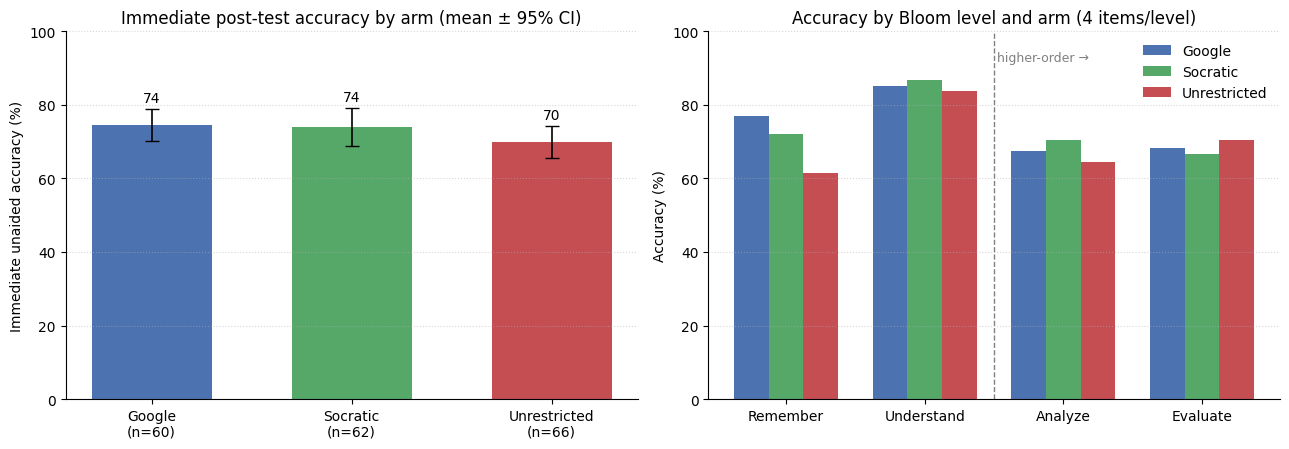

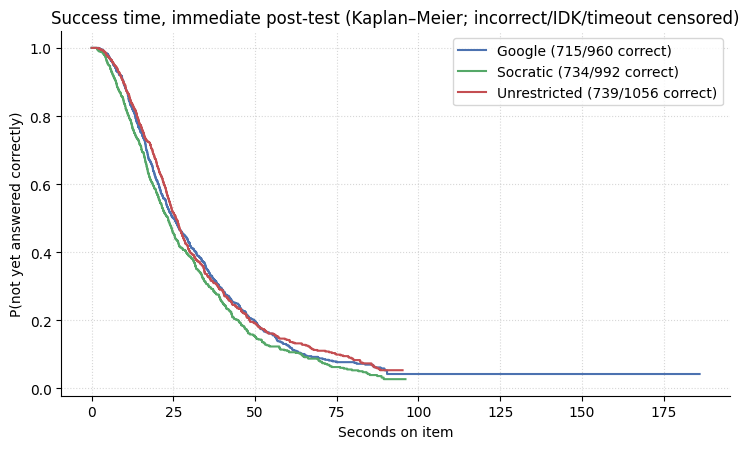

In [10]:
import matplotlib.pyplot as plt
ARM_LABELS = {"google": "Google", "socratic": "Socratic", "unrestricted": "Unrestricted"}
COLORS = {"google": "#4C72B0", "socratic": "#55A868", "unrestricted": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
means, err_lo, err_hi, ns = [], [], [], []
for a in ARM_ORDER:
    x = imm.loc[imm.arm == a, "acc"].dropna().values
    m = x.mean(); lo, hi = _ci95_mean(x)
    means.append(m * 100); err_lo.append((m - lo) * 100); err_hi.append((hi - m) * 100); ns.append(len(x))
bars = ax.bar(range(3), means, 0.6, color=[COLORS[a] for a in ARM_ORDER],
              yerr=[err_lo, err_hi], capsize=5, error_kw=dict(lw=1.2))
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
ax.set_xticks(range(3)); ax.set_xticklabels([f"{ARM_LABELS[a]}\n(n={n})" for a, n in zip(ARM_ORDER, ns)])
ax.set_ylabel("Immediate unaided accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Immediate post-test accuracy by arm (mean ± 95% CI)")
ax.spines[["top", "right"]].set_visible(False); ax.yaxis.grid(True, ls=":", alpha=0.5)

ax = axes[1]
blooms = ["Remember", "Understand", "Analyze", "Evaluate"]
xb = np.arange(len(blooms)); w = 0.25
for i, a in enumerate(ARM_ORDER):
    sub = items_immediate[items_immediate.arm == a]
    accs = [sub.loc[sub.bloom == b, "correct"].mean() * 100 for b in blooms]
    ax.bar(xb + (i - 1) * w, accs, w, label=ARM_LABELS[a], color=COLORS[a])
ax.set_xticks(xb); ax.set_xticklabels(blooms)
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Accuracy by Bloom level and arm (4 items/level)")
ax.axvline(1.5, color="gray", ls="--", lw=1); ax.text(1.52, 92, "higher-order →", fontsize=9, color="gray")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for a in ARM_ORDER:
    s = surv[surv.arm == a]
    KaplanMeierFitter().fit(s["duration_s"], s["event"], label=f"{ARM_LABELS[a]} "
        f"({int(s['event'].sum())}/{len(s)} correct)").plot_survival_function(ax=ax, color=COLORS[a], ci_show=False)
ax.set_xlabel("Seconds on item"); ax.set_ylabel("P(not yet answered correctly)")
ax.set_title("Success time, immediate post-test (Kaplan–Meier; incorrect/IDK/timeout censored)")
ax.spines[["top", "right"]].set_visible(False); ax.grid(True, ls=":", alpha=0.5)
fig.tight_layout(); plt.show()

## 3. Primary analysis: immediate accuracy (sole primary outcome, D3)
### 3.1 Covariate-adjusted ANCOVA — the exact immediate-wave reduction of eq:primary-acc
$$Y_i=\beta_0+\beta_1\mathrm{Soc}_i+\beta_2\mathrm{Unr}_i+\gamma_1\mathrm{VLAT}^c_i+\gamma_2\mathrm{AIUse}^c_i+\varepsilon_i$$
Under D2 the immediate wave is the reference level of the two-wave LMM, so $\beta_2$
(Unrestricted−Google, H1ₐ) and $\beta_1$ (Socratic−Google, H2ₐ) here are the **identical
estimands**; with a single wave the participant random intercept is not separately identified and
REML reduces to OLS. HC3 standard errors; Hedges *g* on the immediate arm contrasts.

In [11]:
PRIMARY_IMM_FORMULA = "acc ~ socratic + unrestricted + minivlat_c + aiuse_c"

def fit_primary_acc_immediate(data):
    _check_covariates(data, ["minivlat_c", "aiuse_c"], "fit_primary_acc_immediate")
    return smf.ols(PRIMARY_IMM_FORMULA, data=data).fit(cov_type="HC3")

res_acc = fit_primary_acc_immediate(imm)
def acc_contrast(Ld):
    return lincom(res_acc, Ld)

def hedges_g(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    if min(n1, n2) < 2: return np.nan
    sp = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    d = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    return d * (1 - 3 / (4 * (n1 + n2 - 2) - 1))

CONTRASTS = {
    "immediate Unrestricted-Google (H1a)":      ({"unrestricted": 1}, ("google", "unrestricted")),
    "immediate Socratic-Google (H2a)":          ({"socratic": 1}, ("google", "socratic")),
    "immediate Socratic-Unrestricted (supp)":   ({"socratic": 1, "unrestricted": -1}, ("unrestricted", "socratic")),
}
rows = []
for lab, (Ld, gpair) in CONTRASTS.items():
    est, se = acc_contrast(Ld); lo, hi = ci95(est, se)
    g = hedges_g(imm.loc[imm.arm == gpair[1], "acc"], imm.loc[imm.arm == gpair[0], "acc"])
    rows.append([lab, est * 100, se * 100, lo * 100, hi * 100, g])
acc_tab = pd.DataFrame(rows, columns=["contrast", "est_pp", "se_pp", "ci95_lo_pp", "ci95_hi_pp",
                                      "hedges_g"]).set_index("contrast")
print(res_acc.summary().tables[1])
print("\nImmediate accuracy contrasts (percentage points, HC3, two-sided 95% CIs):")
acc_tab.round(3)

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.7454      0.020     37.881      0.000       0.707       0.784
socratic        -0.0031      0.032     -0.096      0.924      -0.066       0.060
unrestricted    -0.0483      0.029     -1.645      0.100      -0.106       0.009
minivlat_c       0.0222      0.006      3.547      0.000       0.010       0.035
aiuse_c          0.0191      0.014      1.353      0.176      -0.009       0.047

Immediate accuracy contrasts (percentage points, HC3, two-sided 95% CIs):


,est_pp,se_pp,ci95_lo_pp,ci95_hi_pp,hedges_g
contrast,,,,,
immediate Unrestricted-Google (H1a),-4.83,2.936,-10.584,0.924,-0.259
immediate Socratic-Google (H2a),-0.31,3.227,-6.634,6.015,-0.026
immediate Socratic-Unrestricted (supp),4.52,3.309,-1.966,11.007,0.211


### 3.2 Confirmatory family — fixed-sequence gatekeeper (D3, D6)
Full α = 0.05, one-sided, tested in order; testing **stops at the first non-rejection**:
**(1)** H1ₐ superiority β₂ < 0 → **(2)** H2ₐ non-inferiority (90% CI lower bound of β₁ > −Δ,
Δ = 8.5 pp, required in **ITT ∧ per-protocol**) → **(3)** supporting β₁−β₂ > 0. All three
contrasts are always *estimated* (SAP: quantities beyond a closed gate are reported as estimates
with CIs); the sequence governs only the verdicts. Logic mirrors `sap_estimators.gatekeeper`
verbatim with the single-wave ANCOVA engine.

In [12]:
def gatekeeper_immediate(imm_data, pp_ids, alpha=0.05, delta=0.085, res=None):
    if res is None:
        res = fit_primary_acc_immediate(imm_data)
    b2, se2 = lincom(res, {"unrestricted": 1})                    # H1a  immediate U-G
    b1, se1 = lincom(res, {"socratic": 1})                        # H2a  immediate S-G
    bs, ses = lincom(res, {"socratic": 1, "unrestricted": -1})    # supporting  S-U

    p_h1a = z_onesided_p(b2, se2, -1)
    rej1 = p_h1a < alpha

    lo90_itt = b1 - Z90 * se1
    p_ni_itt = float(st.norm.sf((b1 + delta) / se1))
    ni_itt = lo90_itt > -delta

    lo90_pp, ni_pp, b1_pp, n_pp = np.nan, None, np.nan, len(pp_ids)
    try:
        d_pp = imm_data[imm_data.pid.isin(pp_ids)]
        if d_pp["pid"].nunique() >= 6 and d_pp["arm"].nunique() == 3:
            res_pp = res if len(d_pp) == len(imm_data) else fit_primary_acc_immediate(d_pp)
            b1_pp, se1_pp = lincom(res_pp, {"socratic": 1})
            lo90_pp = b1_pp - Z90 * se1_pp
            ni_pp = bool(lo90_pp > -delta)
    except Exception:
        pass  # ni_pp stays None -> NI cannot be declared

    p_sup = z_onesided_p(bs, ses, +1)
    ni_declared = bool(rej1 and ni_itt and (ni_pp is True))
    rej3 = bool(ni_declared and p_sup < alpha)
    return dict(res=res, b2=b2, se2=se2, ci95_b2=ci95(b2, se2), p_h1a=p_h1a, rej_h1a=rej1,
                b1=b1, se1=se1, ci95_b1=ci95(b1, se1), lo90_itt=lo90_itt, p_ni_itt=p_ni_itt,
                ni_itt=ni_itt, b1_pp=b1_pp, lo90_pp=lo90_pp, ni_pp=ni_pp, n_pp=n_pp,
                ni_declared=ni_declared, bs=bs, ses=ses, ci95_bs=ci95(bs, ses),
                p_sup=p_sup, rej_sup=rej3)

pp_ids = set(aided.loc[aided.engaged == 1, "pid"])
gk = gatekeeper_immediate(imm, pp_ids, alpha=ALPHA, delta=DELTA, res=res_acc)

gate2 = "tested" if gk["rej_h1a"] else "GATE CLOSED (estimate only)"
gate3 = "tested" if gk["ni_declared"] else "GATE CLOSED (estimate only)"
print("FIXED-SEQUENCE GATEKEEPER (one-sided alpha = %.3f | NI margin Delta = %.1f pp)"
      % (ALPHA, DELTA * 100))
print("=" * 78)
lo, hi = gk["ci95_b2"]
print(f"[1] H1a superiority  Unrestricted-Google  est={gk['b2']*100:+.2f} pp "
      f"95%CI[{lo*100:+.2f},{hi*100:+.2f}] one-sided p={gk['p_h1a']:.4f} "
      f"-> {'REJECT H0 (harm supported)' if gk['rej_h1a'] else 'not rejected -> gate closes'}")
lo, hi = gk["ci95_b1"]
print(f"[2] H2a non-inferiority  Socratic-Google  est={gk['b1']*100:+.2f} pp "
      f"95%CI[{lo*100:+.2f},{hi*100:+.2f}]  [{gate2}]")
print(f"      ITT 90%CI lower = {gk['lo90_itt']*100:+.2f} pp vs -Delta = {-DELTA*100:+.1f} pp  "
      f"NI p={gk['p_ni_itt']:.4f} -> {'PASS' if gk['ni_itt'] else 'fail'}")
print(f"      PP  90%CI lower = {gk['lo90_pp']*100:+.2f} pp (n_PP={gk['n_pp']}) -> "
      f"{'PASS' if gk['ni_pp'] else ('fail' if gk['ni_pp'] is False else 'n/a')}")
print(f"      verdict: H2a non-inferiority {'DECLARED (ITT & PP)' if gk['ni_declared'] else 'not declared'}")
lo, hi = gk["ci95_bs"]
print(f"[3] supporting  Socratic-Unrestricted     est={gk['bs']*100:+.2f} pp "
      f"95%CI[{lo*100:+.2f},{hi*100:+.2f}] p={gk['p_sup']:.4f} "
      f"-> {'REJECT (scaffold superior)' if gk['rej_sup'] else 'not rejected'}  [{gate3}]")
print("\nINTERIM NOTE: n = %d of the planned %d. The SAP has no alpha-spending interim plan, so"
      % (imm.pid.nunique(), CONFIG["PLANNED_N"]))
print("these verdicts are provisional monitoring output at the final alpha — the confirmatory")
print("test happens once, on the full sample. Estimates and CIs are exact for the data in hand.")

FIXED-SEQUENCE GATEKEEPER (one-sided alpha = 0.050 | NI margin Delta = 8.5 pp)
[1] H1a superiority  Unrestricted-Google  est=-4.83 pp 95%CI[-10.58,+0.92] one-sided p=0.0500 -> REJECT H0 (harm supported)
[2] H2a non-inferiority  Socratic-Google  est=-0.31 pp 95%CI[-6.63,+6.02]  [tested]
      ITT 90%CI lower = -5.62 pp vs -Delta = -8.5 pp  NI p=0.0056 -> PASS
      PP  90%CI lower = -5.30 pp (n_PP=176) -> PASS
      verdict: H2a non-inferiority DECLARED (ITT & PP)
[3] supporting  Socratic-Unrestricted     est=+4.52 pp 95%CI[-1.97,+11.01] p=0.0860 -> not rejected  [tested]

INTERIM NOTE: n = 188 of the planned 200. The SAP has no alpha-spending interim plan, so
these verdicts are provisional monitoring output at the final alpha — the confirmatory
test happens once, on the full sample. Estimates and CIs are exact for the data in hand.


### 3.3 Interim precision: what this n can and cannot show
Converts the achieved SE of the primary contrast into a minimum detectable effect (MDES, 80%
power, one-sided α = .05) and projects the SE forward to the planned N = 200 under the same
allocation and covariate R². Also locates the NI bound relative to the margin. (Additional
interim-only readout, not part of the SAP.)

In [13]:
z_a, z_80 = st.norm.ppf(1 - ALPHA), st.norm.ppf(0.80)
n_now = imm.pid.nunique()
se_now = gk["se2"]
mdes_now = (z_a + z_80) * se_now
se_200 = se_now * np.sqrt(n_now / CONFIG["PLANNED_N"])
mdes_200 = (z_a + z_80) * se_200
sd_pooled = imm["acc"].std(ddof=1)
print(f"achieved SE of the primary contrast (H1a): {se_now*100:.2f} pp  (n={n_now})")
print(f"  -> MDES @80% power, one-sided .05, at current n : {mdes_now*100:.1f} pp "
      f"(d = {mdes_now/sd_pooled:.2f} at observed SD {sd_pooled:.2f})")
print(f"  -> projected SE at N={CONFIG['PLANNED_N']} (same allocation/R^2): {se_200*100:.2f} pp; "
      f"MDES {mdes_200*100:.1f} pp  (D8 planned ~7.6 pp)")
gap = (gk["lo90_itt"] + DELTA) * 100
print(f"NI headroom vs the -{DELTA*100:.1f} pp margin: {gap:+.2f} pp (positive = NI passes) -> "
      f"{'passes' if gap > 0 else 'fails'} at current n; NI is expected to be unstable this early.")
print(f"Speeder count (median item RT < {CONFIG['SPEEDER_MEDIAN_RT_MS']} ms): {len(speeders)}")

achieved SE of the primary contrast (H1a): 2.94 pp  (n=188)
  -> MDES @80% power, one-sided .05, at current n : 7.3 pp (d = 0.40 at observed SD 0.18)
  -> projected SE at N=200 (same allocation/R^2): 2.85 pp; MDES 7.1 pp  (D8 planned ~7.6 pp)
NI headroom vs the -8.5 pp margin: +2.88 pp (positive = NI passes) -> passes at current n; NI is expected to be unstable this early.
Speeder count (median item RT < 1000 ms): 0


## 4. Key secondary: success time — Cox on the immediate wave (D9-R2 reduction)
Item-level Cox; event = correct answer, incorrect/IDK/timeout right-censored at response time;
participant-clustered robust SEs via the full Lin–Wei sandwich (`sap_estimators.fit_cox_st`).
With one wave the arm×wave columns drop and the arm coefficients **are** the immediate-wave
log-HRs: θ₂ = Unrestricted−Google (H1ᵦ, one-sided, harm = HR < 1), θ₁−θ₂ = supporting H2ᵦ.
The two confirmatory contrasts form their own one-sided Holm family (supporting evidence only —
they never gate the primary claim). PH checked (Grambsch–Therneau); log-normal AFT is the
pre-specified fallback, now with **participant-level cluster-bootstrap inference** (fix
2026-07-16: lifelines AFT fitters have no `cluster_col`, so the earlier naive fit treated each
participant's 16 items as independent — anticonservative p-values; point estimates unchanged).
HR > 1 = faster correct production.

In [14]:
COX_IMM_FORMULA = "socratic + unrestricted + minivlat_c + aiuse_c"
cph = fit_cox_st(surv, formula=COX_IMM_FORMULA, strata=None)
d_cox = surv.dropna(subset=["duration_s", "event", "socratic", "unrestricted",
                            "minivlat_c", "aiuse_c"]).copy()

st_rows = []
for lab, Ld, direction, conf in [
    ("immediate Unrestricted-Google (H1b)",        {"unrestricted": 1},                  -1, True),
    ("immediate Socratic-Google",                  {"socratic": 1},                       0, False),
    ("immediate Socratic-Unrestricted (H2b supp)", {"socratic": 1, "unrestricted": -1},  +1, True),
]:
    est, se = cox_lincom(cph, Ld); lo, hi = ci95(est, se)
    p = z_onesided_p(est, se, direction) if direction else np.nan
    st_rows.append([lab, np.exp(est), np.exp(lo), np.exp(hi), (p if conf else np.nan)])
st_tab = pd.DataFrame(st_rows, columns=["contrast", "HR", "HR_ci95_lo", "HR_ci95_hi",
                                        "one_sided_p"]).set_index("contrast")
_conf = st_tab["one_sided_p"].dropna()
st_tab.loc[_conf.index, "p_holm"] = multipletests(_conf.values, alpha=ALPHA, method="holm")[1]
print(f"Events (correct answers) per arm: "
      f"{surv.groupby('arm', observed=True)['event'].sum().reindex(ARM_ORDER).to_dict()}")
print("\nSuccess-time contrasts (participant-clustered Cox; own Holm family):")
print(st_tab.round(4).to_string())

try:
    ph = proportional_hazard_test(cph, d_cox, time_transform="rank")
    arm_ph = ph.summary.loc[ph.summary.index.isin(["socratic", "unrestricted"]), ["test_statistic", "p"]]
    print("\nPH test (arm terms, Grambsch-Therneau):"); print(arm_ph.round(3).to_string())
    if (arm_ph["p"] < 0.05).any():
        # FIX 2026-07-16 (additive): lifelines AFT fitters have no cluster_col, so the earlier
        # naive LogNormalAFTFitter().fit() treated each participant's 16 items as independent
        # -> anticonservative SEs/p-values (same failure mode the Monte Carlo validation caught
        # on the Cox side, D10). Point estimates are unchanged; inference now comes from a
        # participant-level cluster bootstrap (pids resampled with replacement within arm,
        # refit per replicate, percentile 95% CIs + two-sided sign-flip p) via
        # sap_estimators.fit_aft_fallback. p_naive is kept only to document the correction.
        print("  PH violated -> pre-specified log-normal AFT fallback (time ratios), "
              "participant-cluster bootstrap inference:")
        aft_fb = fit_aft_fallback(d_cox, n_boot=1000, seed=CONFIG["SEED"])
        aft = aft_fb["aft"]          # point fit identical to the previous naive call
        print(aft_fb["table"].round(3).to_string())
        print(f"  bootstrap: {aft_fb['n_ok']}/{aft_fb['n_boot']} refits converged "
              f"(seed {aft_fb['seed']}); percentile CIs; p_boot = two-sided sign-flip (r+1)/(B+1).")
except Exception as e:
    print("PH test not computable on this sample:", type(e).__name__)

Events (correct answers) per arm: {'google': 715, 'socratic': 734, 'unrestricted': 739}

Success-time contrasts (participant-clustered Cox; own Holm family):
                                                HR  HR_ci95_lo  HR_ci95_hi  one_sided_p  p_holm
contrast                                                                                       
immediate Unrestricted-Google (H1b)         0.9645      0.8106      1.1476       0.3418  0.3418
immediate Socratic-Google                   1.1613      0.9916      1.3599          NaN     NaN
immediate Socratic-Unrestricted (H2b supp)  1.2040      1.0079      1.4383       0.0204  0.0407

PH test (arm terms, Grambsch-Therneau):
              test_statistic      p
socratic               0.803  0.370
unrestricted           0.137  0.712


## 5. Secondary confirmatory I: Bloom-level concentration (H4ₐ)
Binary lower/higher-order × arm interaction on the immediate post-test, item level (8 items per
side). Focal term = Unrestricted × higher-order, one-sided (β₅ < 0 = deficit concentrates at
higher order). Confirmatory engine = participant-clustered logistic GEE (D10); the crossed-RE
Bayesian GLMM is corroboration only (its variational SDs are anticonservative), and the
interaction is also expressed as an average marginal interaction contrast (AMIC) on the
probability scale.

**Interim multiplicity note.** H4ₐ's pre-registered family is Holm over {H4ₐ, H5ₐ}; H5ₐ needs the
delayed wave, so the family cannot close here. The cell reports the one-sided *p* against both
reference points: α = .05 (nominal / best case, H4ₐ smallest-p) and α/2 = .025 (the bound H4ₐ
must beat if it carries the smaller Holm-ordered p once H5ₐ joins).

In [15]:
ub = surv[surv["order"].notna()].copy()
ub["order_hi"] = (ub["order"] == "higher").astype(int)
print("Immediate accuracy by arm x order:")
print(ub.pivot_table(index="order", columns="arm", values="correct", observed=True).round(3).to_string())

gee = fit_bloom_gee(ub)
b5, se5, p_h4a = h4a_from_gee(gee)                  # H1: b5 < 0
lo, hi = ci95(b5, se5)
print(f"\nH4a focal interaction (Unrestricted x higher-order), log-odds: est={b5:+.4f} "
      f"95%CI[{lo:+.4f},{hi:+.4f}] one-sided p={p_h4a:.4f}")
print(f"  vs alpha = {ALPHA}: {'reject' if p_h4a < ALPHA else 'not rejected'} (nominal)"
      f" | vs alpha/2 = {ALPHA/2}: {'reject' if p_h4a < ALPHA/2 else 'not rejected'}"
      " (worst-case Holm share once H5a joins the family)")

def _pred(dfx): return gee.predict(dfx)
base = ub.copy()
def setarm(a):
    x = base.copy(); x["socratic"] = int(a == "socratic"); x["unrestricted"] = int(a == "unrestricted")
    return x
amic_rows = {}
for a in ["google", "unrestricted", "socratic"]:
    xa = setarm(a); xhi = xa.copy(); xhi["order_hi"] = 1; xlo = xa.copy(); xlo["order_hi"] = 0
    amic_rows[a] = float(_pred(xhi).mean() - _pred(xlo).mean())
amic = amic_rows["unrestricted"] - amic_rows["google"]
print(f"AMIC (probability scale) Unrestricted-vs-Google hi-minus-lo diff-in-diffs = {amic:+.4f}")

try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    bm = BinomialBayesMixedGLM.from_formula(
        "correct ~ (socratic + unrestricted) * order_hi + minivlat_c + aiuse_c",
        {"pid": "0 + C(pid)", "item": "0 + C(item_id)"}, ub).fit_vb()
    sd = pd.Series(np.asarray(bm.fe_sd), index=bm.model.exog_names)
    fe = pd.DataFrame({"post_mean": bm.fe_mean, "post_sd": sd})
    print("\nCrossed-RE Bayesian GLMM (corroboration only; VB SDs anticonservative):")
    print(fe[fe.index.str.contains(":")].round(3).to_string())
except Exception as e:
    print("\nCrossed-RE VB GLMM not computable on this sample:", type(e).__name__)

Immediate accuracy by arm x order:
arm     google  socratic  unrestricted
order                                 
higher   0.679     0.685         0.674
lower    0.810     0.794         0.725

H4a focal interaction (Unrestricted x higher-order), log-odds: est=+0.4704 95%CI[+0.0542,+0.8866] one-sided p=0.9866
  vs alpha = 0.05: not rejected (nominal) | vs alpha/2 = 0.025: not rejected (worst-case Holm share once H5a joins the family)


AMIC (probability scale) Unrestricted-vs-Google hi-minus-lo diff-in-diffs = +0.0805



Crossed-RE Bayesian GLMM (corroboration only; VB SDs anticonservative):
                       post_mean  post_sd
socratic:order_hi          0.119    0.107
unrestricted:order_hi      0.543    0.101


## 6. Secondary confirmatory II: persistence (H5ₐ) — **pending the 72 h wave**
Not estimable from immediate data, by construction:

- **H5ₐ** (accuracy persistence) = delayed-wave simple effect β₂+β₅ < 0, one-sided (D9-R1) —
  needs `wave_d = 1` rows in the two-wave LMM.
- **H5ᵦ** (success-time persistence, exploratory) = delayed combinations θ₂+θ₄ of the arm×wave
  Cox (D9-R2) — same requirement.
- The secondary confirmatory Holm family {H4ₐ, H5ₐ} therefore stays **open** (see §5's interim
  bounds).

**When the delayed export lands**: run `rct_data_literacy_analysis_4_FINAL.ipynb` (v4), which
merges the delayed survey by `PROLIFIC_PID` and estimates all of the above with the shared,
validated estimators (`fit_primary_acc`, `h5a_simple_effect`, wave-stratified `fit_cox_st`,
MICE + Lee bounds). This notebook intentionally does not duplicate that machinery.

In [16]:
print("H5a / H5b persistence: PENDING - requires the 72h delayed-retest export.")
print("Holm family {H4a, H5a}: OPEN (interim bounds for H4a reported in section 5).")
print("Two-wave machinery lives in rct_data_literacy_analysis_4_FINAL.ipynb (v4).")

H5a / H5b persistence: PENDING - requires the 72h delayed-retest export.
Holm family {H4a, H5a}: OPEN (interim bounds for H4a reported in section 5).
Two-wave machinery lives in rct_data_literacy_analysis_4_FINAL.ipynb (v4).


## 7. Productivity during the aided block (H3) — BH-FDR family, plus tool-use profile
Assisted-side of the trade-off (exploratory family, BH-FDR q = .05, one-sided): aided accuracy,
log time-per-item, log rate-correct-score, and the aided success-time Cox. Doubles as the
affordance manipulation check. The tool-use table profiles what each arm actually did.

In [17]:
print("Tool use and productivity by arm (aided practice block):")
tu = (aided.groupby("arm", observed=True)
      .agg(n=("pid", "size"), aided_acc=("aided_acc", "mean"), minutes_med=("minutes", "median"),
           turns_med=("n_turns", "median"), queries_med=("n_queries", "median"),
           clicks_med=("n_clicks", "median"), rcs_med=("rcs", "median"),
           engaged=("engaged", "mean")).reindex(ARM_ORDER))
print(tu.round(2).to_string())

prod_rows = []
for dv in ["aided_acc", "log_time_per_item", "log_rcs"]:
    r = smf.ols(f"{dv} ~ socratic + unrestricted + minivlat_c + aiuse_c", data=aided).fit(cov_type="HC3")
    for arm_d in ["unrestricted", "socratic"]:
        est = float(r.params[arm_d])
        direction = -1 if dv == "log_time_per_item" else +1
        prod_rows.append(dict(outcome=dv, contrast=f"{arm_d}-google", est=est,
                              p=z_onesided_p(est, float(r.bse[arm_d]), direction)))

ev_arm = aided_surv.groupby("arm", observed=True)["event"].sum().reindex(ARM_ORDER)
if (ev_arm > 0).all():
    ca = fit_cox_st(aided_surv, formula="socratic + unrestricted + minivlat_c + aiuse_c", strata=None)
    for arm_d in ["unrestricted", "socratic"]:
        est, se = cox_lincom(ca, {arm_d: 1})
        prod_rows.append(dict(outcome="aided success (logHR)", contrast=f"{arm_d}-google",
                              est=est, p=z_onesided_p(est, se, +1)))
else:
    print("Aided Cox skipped (an arm has zero correct answers).")

prod = pd.DataFrame(prod_rows)
prod["p_BH"] = multipletests(prod["p"], alpha=0.05, method="fdr_bh")[1]
print("\nProductivity family (one-sided, BH-FDR q = .05):")
print(prod.round(4).to_string())

Tool use and productivity by arm (aided practice block):
               n  aided_acc  minutes_med  turns_med  queries_med  clicks_med  rcs_med  engaged
arm                                                                                           
google        60       0.63         7.58        0.0          3.0         2.5     0.74     0.90
socratic      62       0.60         7.38        5.0          0.0         0.0     0.53     0.98
unrestricted  66       0.73         6.71        8.0          0.0         0.0     0.86     0.92



Productivity family (one-sided, BH-FDR q = .05):
                 outcome             contrast     est       p    p_BH
0              aided_acc  unrestricted-google  0.0986  0.0002  0.0016
1              aided_acc      socratic-google -0.0226  0.7310  0.9880
2      log_time_per_item  unrestricted-google -0.0215  0.4087  0.8174
3      log_time_per_item      socratic-google  0.1728  0.9342  0.9880
4                log_rcs  unrestricted-google  0.2616  0.0370  0.0986
5                log_rcs      socratic-google -0.1997  0.8810  0.9880
6  aided success (logHR)  unrestricted-google  0.1999  0.0133  0.0534
7  aided success (logHR)      socratic-google -0.2326  0.9880  0.9880


## 8. Exploratory moderation — prior knowledge × outsourcing (worked-example paradox)
Arm × continuous baseline Mini-VLAT on immediate accuracy. Exploratory: no confirmatory family,
estimates with 95% CIs, no directional verdict. A deficit **growing** with prior skill
(negative Unrestricted × Mini-VLAT) would implicate the expertise-reversal / redundancy account.

In [18]:
mod = smf.ols("acc ~ (socratic + unrestricted) * minivlat_c + aiuse_c", data=imm).fit(cov_type="HC3")
for term in ["unrestricted:minivlat_c", "socratic:minivlat_c"]:
    est = float(mod.params[term]); lo, hi = ci95(est, float(mod.bse[term]))
    print(f"{term:26s}  est={est:+.4f}  95%CI[{lo:+.4f}, {hi:+.4f}]  (exploratory, no verdict)")
print("Negative Unrestricted x MiniVLAT = deficit grows with prior visualisation literacy.")

unrestricted:minivlat_c     est=-0.0196  95%CI[-0.0481, +0.0090]  (exploratory, no verdict)
socratic:minivlat_c         est=-0.0108  95%CI[-0.0406, +0.0190]  (exploratory, no verdict)
Negative Unrestricted x MiniVLAT = deficit grows with prior visualisation literacy.


## 9. Robustness analyses (SAP order, immediate-anchored)
R1 unadjusted contrasts; R2 Lin (2013) fully-interacted estimator; R3 fractional logit
(Papke–Wooldridge QMLE) with average marginal effects; R4 item-level participant-clustered GEE;
R5 randomisation inference (the design-justified small-sample check); R6 IDK-scoring sensitivity;
R8 speeder exclusion (1,000 ms rule). R7 and the missing-data battery are delayed-wave-dependent
(§12). At this interim n, R5 is the inference to trust most.

In [19]:
print("R1. Unadjusted immediate differences in means (Welch) + unadjusted Cox")
for a1, a2 in [("google", "unrestricted"), ("google", "socratic"), ("socratic", "unrestricted")]:
    x, y = imm.loc[imm.arm == a1, "acc"], imm.loc[imm.arm == a2, "acc"]
    if min(len(x), len(y)) >= 2:
        t, p = st.ttest_ind(y, x, equal_var=False)
        print(f"   {a2}-{a1}: diff={(y.mean()-x.mean())*100:+.2f} pp  Welch two-sided p={p:.3f}")
cu = fit_cox_st(surv, formula="socratic + unrestricted", strata=None)
print("   unadjusted Cox HR:", {k: round(float(np.exp(v)), 3) for k, v in cu.params_.items()})

print("\nR2. Lin (2013) fully interacted estimator (HC3), immediate")
r2 = smf.ols("acc ~ (socratic + unrestricted) * (minivlat_c + aiuse_c)", data=imm).fit(cov_type="HC3")
print(f"   unrestricted={r2.params['unrestricted']*100:+.2f} pp (p={r2.pvalues['unrestricted']:.3f}), "
      f"socratic={r2.params['socratic']*100:+.2f} pp (p={r2.pvalues['socratic']:.3f})")

print("\nR3. Fractional logit (Papke-Wooldridge QMLE), immediate, AME")
X = sm.add_constant(imm[["socratic", "unrestricted", "minivlat_c", "aiuse_c"]].astype(float))
g3 = sm.GLM(imm["acc"].astype(float), X, family=sm.families.Binomial()).fit(cov_type="HC3")
ame = {}
for arm_d in ["socratic", "unrestricted"]:
    X1, X0 = X.copy(), X.copy(); other = "unrestricted" if arm_d == "socratic" else "socratic"
    X1[arm_d], X1[other] = 1.0, 0.0; X0[arm_d], X0[other] = 0.0, 0.0
    ame[arm_d] = float(np.mean(g3.predict(X1) - g3.predict(X0)))
print(f"   AME unrestricted={ame['unrestricted']*100:+.2f} pp (p={g3.pvalues['unrestricted']:.3f}), "
      f"AME socratic={ame['socratic']*100:+.2f} pp (p={g3.pvalues['socratic']:.3f})")

R1. Unadjusted immediate differences in means (Welch) + unadjusted Cox
   unrestricted-google: diff=-4.50 pp  Welch two-sided p=0.146
   socratic-google: diff=-0.49 pp  Welch two-sided p=0.886
   unrestricted-socratic: diff=-4.01 pp  Welch two-sided p=0.236


   unadjusted Cox HR: {'socratic': 1.145, 'unrestricted': 0.972}

R2. Lin (2013) fully interacted estimator (HC3), immediate
   unrestricted=-4.83 pp (p=0.110), socratic=-0.15 pp (p=0.962)

R3. Fractional logit (Papke-Wooldridge QMLE), immediate, AME
   AME unrestricted=-4.81 pp (p=0.094), AME socratic=-0.23 pp (p=0.940)


In [20]:
print("R4. Item-level participant-clustered GEE (immediate), arm main effects (log-odds)")
try:
    gee4 = smf.gee("correct ~ socratic + unrestricted + minivlat_c + aiuse_c",
                   groups="pid", data=surv, family=sm.families.Binomial(),
                   cov_struct=sm.cov_struct.Exchangeable()).fit()
    print("   GEE log-odds:", {k: round(float(gee4.params[k]), 3) for k in ["socratic", "unrestricted"]})
except Exception as e:
    print("   not computable on this sample:", type(e).__name__)

print(f"\nR5. Randomisation inference on the immediate estimands ({CONFIG['N_PERMUTATIONS']} perms; "
      "set 10000 for the final report)")
def immediate_stats(arm_map):
    di = imm.copy(); di["arm2"] = di["pid"].map(arm_map)
    di["soc"] = (di.arm2 == "socratic").astype(int); di["unr"] = (di.arm2 == "unrestricted").astype(int)
    a = smf.ols("acc ~ soc + unr + minivlat_c + aiuse_c", data=di).fit().params["unr"]
    si = surv.copy(); si["arm2"] = si["pid"].map(arm_map)
    si["soc"] = (si.arm2 == "socratic").astype(int); si["unr"] = (si.arm2 == "unrestricted").astype(int)
    c = CoxPHFitter().fit(si[["duration_s", "event", "soc", "unr", "minivlat_c", "aiuse_c"]],
                          "duration_s", "event", formula="soc + unr + minivlat_c + aiuse_c")
    return a, float(c.params_["unr"])
true_map = dict(zip(covars["pid"], covars["arm"].astype(str)))
obs_a, obs_c = immediate_stats(true_map)
pids, labels = list(true_map), np.array(list(true_map.values()))
pa, pc = [], []
for _ in range(CONFIG["N_PERMUTATIONS"]):
    pm = dict(zip(pids, rng.permutation(labels)))
    try:
        a, c = immediate_stats(pm); pa.append(a); pc.append(c)
    except Exception:
        continue
print(f"   accuracy U-G beta={obs_a*100:+.2f} pp  two-sided RI p={(np.sum(np.abs(pa) >= abs(obs_a)) + 1) / (len(pa) + 1):.3f}"
      f"  one-sided (harm) RI p={(np.sum(np.array(pa) <= obs_a) + 1) / (len(pa) + 1):.3f}")
print(f"   success  U-G logHR={obs_c:+.3f}   two-sided RI p={(np.sum(np.abs(pc) >= abs(obs_c)) + 1) / (len(pc) + 1):.3f}"
      f"  one-sided (harm) RI p={(np.sum(np.array(pc) <= obs_c) + 1) / (len(pc) + 1):.3f}"
      f"   ({len(pa)} valid perms)")

R4. Item-level participant-clustered GEE (immediate), arm main effects (log-odds)
   GEE log-odds: {'socratic': -0.012, 'unrestricted': -0.244}

R5. Randomisation inference on the immediate estimands (1000 perms; set 10000 for the final report)


   accuracy U-G beta=-4.83 pp  two-sided RI p=0.141  one-sided (harm) RI p=0.083
   success  U-G logHR=-0.036   two-sided RI p=0.686  one-sided (harm) RI p=0.345   (1000 valid perms)


In [21]:
print("R6. IDK scoring sensitivity: accuracy among ATTEMPTED items (IDK/timeout dropped)")
att6 = items_immediate[~items_immediate["idk"] & ~items_immediate["timeout"]]
alt = (att6.groupby("pid")["correct"].mean().rename("acc").reset_index()
       .merge(covars, on="pid"))
if alt["pid"].nunique() >= 6 and alt["arm"].nunique() == 3:
    ra = fit_primary_acc_immediate(alt)
    for lab, Ld in [("U-G", {"unrestricted": 1}), ("S-G", {"socratic": 1})]:
        est, se = lincom(ra, Ld)
        print(f"   attempted-only immediate {lab}: est={est*100:+.2f} pp "
              f"(one-sided p={z_onesided_p(est, se, -1):.3f})")
else:
    print("   too few participants with attempted items.")

print(f"\nR8. Speeder exclusion (median item RT < {CONFIG['SPEEDER_MEDIAN_RT_MS']} ms): "
      f"n excluded = {len(speeders)}")
keep = imm[~imm["pid"].isin(speeders)]
if len(speeders) == 0:
    print("   no speeders -> identical to the primary fit.")
elif keep["pid"].nunique() >= 6 and keep["arm"].nunique() == 3:
    rk = fit_primary_acc_immediate(keep)
    est, se = lincom(rk, {"unrestricted": 1})
    print(f"   immediate U-G after exclusion: est={est*100:+.2f} pp "
          f"(one-sided p={z_onesided_p(est, se, -1):.3f})")
else:
    print("   too few participants remain after exclusion.")

R6. IDK scoring sensitivity: accuracy among ATTEMPTED items (IDK/timeout dropped)
   attempted-only immediate U-G: est=-1.97 pp (one-sided p=0.231)
   attempted-only immediate S-G: est=-0.67 pp (one-sided p=0.412)

R8. Speeder exclusion (median item RT < 1000 ms): n excluded = 0
   no speeders -> identical to the primary fit.


## 10. Compliance, contamination, complier effects
Compliance = ≥1 assigned-tool interaction during the aided block. CACE by the one-sided
noncompliance Wald estimator (instrumented exposure = use of the *assigned* tool; first stage =
treated-arm engagement — the formulation validated in D10, Check 8). Contamination screen flags
Google-arm queries that mention an LLM tool.

In [22]:
comp = aided[["pid", "arm", "engaged"]].merge(imm[["pid", "acc"]], on="pid", how="inner")
print("Compliance (>=1 assigned-tool interaction) by arm:")
print(comp.groupby("arm", observed=True)["engaged"].mean().round(2).to_string())
for a1, a2 in [("google", "unrestricted"), ("google", "socratic")]:
    dd = comp[comp.arm.isin([a1, a2])]; z = (dd.arm == a2).astype(int)
    itt = dd.acc[z == 1].mean() - dd.acc[z == 0].mean()
    first = dd.engaged[z == 1].mean()
    cace = itt / first if first > 1e-9 else np.nan
    print(f"  {a2} vs {a1}: ITT={itt*100:+.2f} pp  first-stage (treated engagement)={first:.2f}  "
          f"CACE={'undefined (no compliance)' if np.isnan(cace) else f'{cace*100:+.2f} pp'}")

llm_terms = ("chatgpt", "gpt", "claude", "gemini", "copilot", "llm", " ai ")
gq = [q.lower() for qs in items_train.loc[items_train.arm == "google", "queries"] for q in qs]
hits = [q for q in gq if any(t in f" {q} " for t in llm_terms)]
print(f"\nContamination screen: {len(hits)}/{len(gq)} Google-arm queries mention an LLM tool")
if hits: print("   flagged:", hits[:10])

Compliance (>=1 assigned-tool interaction) by arm:
arm
google          0.90
socratic        0.98
unrestricted    0.92
  unrestricted vs google: ITT=-4.50 pp  first-stage (treated engagement)=0.92  CACE=-4.87 pp
  socratic vs google: ITT=-0.49 pp  first-stage (treated engagement)=0.98  CACE=-0.50 pp

Contamination screen: 0/193 Google-arm queries mention an LLM tool


## 11. Manipulation checks and reliability
Checks inform interpretation only — never outcome-based exclusion. **11.1** Leppink
cognitive-load gradient (predicted: germane lowest in Unrestricted; extraneous highest in Google).
**11.2** KR-20. **11.3** Socratic fidelity telemetry (LLM judge). **11.4** Answer-adoption
latency Δ (D11) — live in this export; per D11 this pilot's Δ distribution **locks** the
direct-adoption cutoff (default 5 s), so the quantile table below is the locking evidence.

In [23]:
print("MC1. Cognitive-load gradient (Leppink subscales), covariate-adjusted arm effects")
print("     Predicted: germane LOWEST in Unrestricted; extraneous HIGHEST in Google.")
for col, name in [("IL_ave", "Intrinsic"), ("EL_ave", "Extraneous"), ("GL_ave", "Germane")]:
    ok = df.dropna(subset=[col])
    if ok["arm"].nunique() < 3 or len(ok) < 9:
        print(f"  {name}: insufficient data, skipped."); continue
    r = smf.ols(f"{col} ~ socratic + unrestricted + minivlat_c + aiuse_c", data=ok).fit(cov_type="HC3")
    means = ok.groupby("arm", observed=True)[col].mean().round(2).reindex(ARM_ORDER).to_dict()
    print(f"  {name}: arm means {means} | soc={r.params['socratic']:+.2f}(p={r.pvalues['socratic']:.2f}) "
          f"unr={r.params['unrestricted']:+.2f}(p={r.pvalues['unrestricted']:.2f})")
if df["tlx"].notna().any():
    print("  NASA-TLX (mean of 5 sliders) by arm:",
          df.groupby("arm", observed=True)["tlx"].mean().round(1).to_dict())

print(f"\nMC2. KR-20: immediate 16-item block = {kr20(items_immediate):.2f} | "
      f"Mini-VLAT baseline = {mv_kr20:.2f}")

soc = items_train[items_train["arm"] == "socratic"]
fids = [f for lst in soc["judge_fidelities"] for f in lst]
if fids:
    print(f"\nMC3. Socratic fidelity telemetry: turns={int(soc['n_turns'].sum())} "
          f"mean fidelity={np.mean(fids):.2f} (1-5 scale) | share < 3: {np.mean(np.array(fids) < 3):.2%} "
          f"| regen rate={soc['n_regen'].sum() / max(int(soc['n_turns'].sum()), 1):.2%}")
else:
    print("\nMC3. No Socratic judge telemetry in this export.")

_ad = items_train[["pid", "arm", "adopt_delta_s"]]
adopt_res = None
if _ad["adopt_delta_s"].notna().any():
    adopt_res = adoption_latency(_ad, threshold_s=CONFIG["ADOPTION_LATENCY_THRESHOLD_S"])
    _r = adopt_res
    print("\nMC4. Answer-adoption latency Delta (last tool interaction -> answer submission):")
    for _, _row in _r["dist"].iterrows():
        print(f"    {_row['arm']:>12}: median {_row['median']:.1f}s [IQR {_row['q25']:.1f}-{_row['q75']:.1f}]  n={int(_row['n'])}")
    print(f"    items excluded (no tool interaction on the item): {_r['n_excluded']}")
    _c = _r["contrast"]
    if _c:
        print(f"    log-Delta Unrestricted-Socratic: est={_c['est']:+.3f} "
              f"95%CI[{_c['ci95'][0]:+.3f},{_c['ci95'][1]:+.3f}] one-sided p={_c['p_onesided']:.4f} "
              "(Unrestricted predicted shorter = answer outsourcing)")
    print(f"    direct-adoption rate @ {_r['threshold_s']:.0f}s: "
          + str({k: round(v, 3) for k, v in _r['adoption_rate'].items()}))
    _dd = _ad.dropna(subset=["adopt_delta_s"])
    qtab = (_dd.groupby("arm", observed=True)["adopt_delta_s"]
            .quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack().reindex(ARM_ORDER))
    print("\n    THRESHOLD-LOCKING TABLE (pilot Delta quantiles, seconds — D11):")
    print(qtab.round(1).to_string())
    print(f"    share of tool-items with Delta < 5 s, by arm: "
          + str(_dd.assign(u=_dd['adopt_delta_s'] < 5).groupby('arm', observed=True)['u'].mean().round(3).to_dict()))
else:
    print("\nMC4. Answer-adoption latency: timestamps absent from this export.")

MC1. Cognitive-load gradient (Leppink subscales), covariate-adjusted arm effects
     Predicted: germane LOWEST in Unrestricted; extraneous HIGHEST in Google.
  Intrinsic: arm means {'google': 7.27, 'socratic': 7.54, 'unrestricted': 7.33} | soc=+0.27(p=0.47) unr=+0.10(p=0.80)
  Extraneous: arm means {'google': 4.19, 'socratic': 5.44, 'unrestricted': 4.03} | soc=+1.24(p=0.00) unr=-0.18(p=0.65)
  Germane: arm means {'google': 5.36, 'socratic': 4.73, 'unrestricted': 4.48} | soc=-0.75(p=0.11) unr=-0.99(p=0.01)

MC2. KR-20: immediate 16-item block = 0.70 | Mini-VLAT baseline = 0.77

MC3. Socratic fidelity telemetry: turns=393 mean fidelity=3.54 (1-5 scale) | share < 3: 6.43% | regen rate=0.00%



MC4. Answer-adoption latency Delta (last tool interaction -> answer submission):
          google: median 21.8s [IQR 8.6-49.6]  n=156
        socratic: median 24.3s [IQR 12.8-37.4]  n=195
    unrestricted: median 11.7s [IQR 6.1-23.6]  n=376
    items excluded (no tool interaction on the item): 777
    log-Delta Unrestricted-Socratic: est=-0.564 95%CI[-0.775,-0.353] one-sided p=0.0000 (Unrestricted predicted shorter = answer outsourcing)
    direct-adoption rate @ 5s: {'google': 0.079, 'socratic': 0.05, 'unrestricted': 0.158}

    THRESHOLD-LOCKING TABLE (pilot Delta quantiles, seconds — D11):
              0.10  0.25  0.50  0.75  0.90
arm                                       
google         5.2   8.6  21.8  49.6  93.2
socratic       7.0  12.8  24.3  37.4  66.2
unrestricted   3.9   6.1  11.7  23.6  45.5
    share of tool-items with Delta < 5 s, by arm: {'google': 0.083, 'socratic': 0.067, 'unrestricted': 0.165}


### 11.4b Adoption-latency distribution (threshold-locking figure)

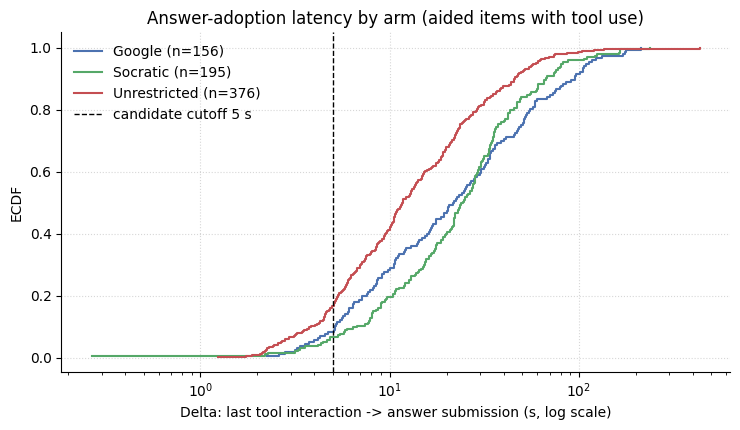

In [24]:
_dd = items_train.dropna(subset=["adopt_delta_s"])
if len(_dd):
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    for a in ARM_ORDER:
        x = np.sort(_dd.loc[_dd.arm == a, "adopt_delta_s"].values)
        if len(x) == 0: continue
        ax.step(x, np.arange(1, len(x) + 1) / len(x), where="post",
                label=f"{ARM_LABELS[a]} (n={len(x)})", color=COLORS[a])
    ax.axvline(CONFIG["ADOPTION_LATENCY_THRESHOLD_S"], color="k", ls="--", lw=1,
               label=f"candidate cutoff {CONFIG['ADOPTION_LATENCY_THRESHOLD_S']} s")
    ax.set_xscale("log")
    ax.set_xlabel("Delta: last tool interaction -> answer submission (s, log scale)")
    ax.set_ylabel("ECDF"); ax.set_title("Answer-adoption latency by arm (aided items with tool use)")
    ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, ls=":", alpha=0.5)
    fig.tight_layout(); plt.show()
else:
    print("No adoption-latency data to plot.")

## 12. Attrition and missing data — immediate-wave accounting
With one wave the full missing-data battery (differential-dropout logit for the 72 h retest,
MICE with the D10 MMRM-over-MICE precommitment, Lee bounds) is pending. What is checkable now:
completion of the immediate session among randomised participants, by arm.

In [25]:
rand = raw.copy()
rand["pid"] = rand.get("PROLIFIC_PID", rand["ResponseId"]).fillna(rand["ResponseId"]).astype(str)
a = rand["arm"].astype(str).str.strip().str.lower().replace({"nan": np.nan})
a = a.mask(a.isna() & rand["Condition"].astype(str).str.upper().eq("SEARCH"), "google")
rand["arm"] = pd.Categorical(a, ARM_ORDER, ordered=True)
rand = rand.dropna(subset=["arm"]).drop_duplicates("pid")[["pid", "arm"]]
rand["socratic"] = (rand.arm == "socratic").astype(int)
rand["unrestricted"] = (rand.arm == "unrestricted").astype(int)
rand["completed_immediate"] = rand.pid.isin(set(items_immediate["pid"])).astype(int)
print(f"Randomised (reached arm assignment): {len(rand)} | completed immediate post-test: "
      f"{int(rand['completed_immediate'].sum())}")
print(rand.groupby("arm", observed=True)["completed_immediate"].agg(["count", "mean"]).round(2).to_string())
if 0 < rand["completed_immediate"].mean() < 1:
    try:
        lg = smf.logit("completed_immediate ~ socratic + unrestricted", data=rand).fit(disp=0)
        print("\nDifferential-completion logit (immediate | randomised):")
        print(lg.params.round(3).to_string())
    except Exception as e:
        print("\nCompletion logit not estimable:", type(e).__name__)
else:
    print("\nNo within-session attrition after randomisation -> completion logit degenerate (all 1s).")
print("\nPending with the delayed wave: dropout logit, MICE (m=50; MMRM pre-committed over MICE "
      "per D10), two-sided Lee bounds.")

Randomised (reached arm assignment): 197 | completed immediate post-test: 188
              count  mean
arm                      
google           66  0.91
socratic         65  0.95
unrestricted     66  1.00

Differential-completion logit (immediate | randomised):
Intercept        2.303
socratic         0.726
unrestricted    20.616

Pending with the delayed wave: dropout logit, MICE (m=50; MMRM pre-committed over MICE per D10), two-sided Lee bounds.


## 13. Run log and what remains for the full analysis
**Runs in this notebook (immediate-only):** CONSORT accounting; balance; psychometrics (KR-20,
item analysis); primary ANCOVA + fixed-sequence gatekeeper (H1ₐ → H2ₐ NI ITT∧PP → supporting);
interim precision/MDES; success-time Cox (H1ᵦ + supporting, own Holm family, PH check);
H4ₐ Bloom GEE + AMIC + VB-GLMM corroboration (interim Holm bounds); productivity BH-FDR + tool
use; exploratory prior-knowledge moderation; robustness R1–R6, R8 (incl. randomisation
inference); compliance/CACE/contamination; manipulation checks incl. the D11 adoption-latency Δ
with the threshold-locking table; immediate completion accounting.

**Pending the 72 h delayed wave (run v4 = `rct_data_literacy_analysis_4_FINAL.ipynb`):** H5ₐ
persistence (β₂+β₅), closure of the Holm family {H4ₐ, H5ₐ}, H5ᵦ exploratory Cox combinations,
delayed-wave KR-20, dropout logit, MICE (MMRM pre-committed), Lee bounds.

**Before the full-sample confirmatory run:** set `N_PERMUTATIONS = 10000`; keep the thresholds
locked (speeder 1,000 ms; adoption cutoff per §11.4's locking table); re-estimate the pp-scale
MDES from this pilot's control-arm P0 and KR-20 via `power_analysis_v2.py` (D8 plan).

## 14. Projection to higher N — precision-only what-if
**Read this as a conditional, not a forecast.** With n≈9–10 per arm the point estimates below are
extraordinarily noisy (the primary contrast's 95% CI spans ±20 pp); early extreme estimates regress
toward the truth (winner's curse). The projection **holds each current point estimate fixed** and
shrinks only the SE as $\mathrm{SE}_N=\mathrm{SE}_n\sqrt{n/N}$ (events scale with participants for the
Cox contrasts). So it answers one question only: *given the precision this design buys, at what N
would an effect of the currently observed size become detectable?* It says nothing about whether the
effect really is that size. The covariate R² is held at its observed value; a separate row shows H1ₐ
if Mini-VLAT+AIUse recover to the D8-planned R²=.30.

In [26]:
proj_rows = [
    ("H1a  accuracy  U-G (harm, <0)",      gk["b2"], gk["se2"], -1, "pp"),
    ("H1b  success-time U-G (harm, <0)",  *cox_lincom(cph, {"unrestricted": 1}), -1, "logHR"),
    ("H4a  Bloom interaction (<0)",        b5, se5, -1, "logOR"),
    ("H2b  supp success-time S>U (>0)",   *cox_lincom(cph, {"socratic": 1, "unrestricted": -1}), +1, "logHR"),
    ("supp accuracy S>U (>0)",             gk["bs"], gk["ses"], +1, "pp"),
]
n_now = imm.pid.nunique(); Ns = [60, 100, 150, 200]
print(f"PROJECTED one-sided p, holding the point estimate, SE ~ sqrt(n/N)  [n_now={n_now}]")
print(f"{'estimand':34s}{'est':>10} |  " + "   ".join(f"N={N:<4d}" for N in Ns) + "   N* for p<.05")
print("-" * 92)
for lab, est, se, d, u in proj_rows:
    disp = f"{est*100:+.2f}pp" if u == "pp" else f"{est:+.3f}"
    ps = [z_onesided_p(est, se * np.sqrt(n_now / N), d) for N in Ns]
    aligned = ((d < 0 and est < 0) or (d > 0 and est > 0))
    Nstar = f"{int(np.ceil(n_now * (se / (abs(est) / st.norm.ppf(1-ALPHA)))**2))}" if aligned else "never (wrong sign)"
    print(f"{lab:34s}{disp:>10} |  " + "   ".join(f"{p:5.3f}" for p in ps) + f"    {Nstar}")

print("\nH2a NON-INFERIORITY (Socratic-Google): lower 90% CI bound vs the -8.5 pp margin")
for N in Ns:
    seN = gk["se1"] * np.sqrt(n_now / N); lo = (gk["b1"] - Z90 * seN) * 100
    print(f"   N={N:3d}: est {gk['b1']*100:+.2f} pp, lower90 {lo:+.2f} pp -> {'PASS' if lo > -DELTA*100 else 'FAIL'}")
print(f"   The point estimate {gk['b1']*100:+.2f} pp is {'BEYOND' if gk['b1'] < -DELTA else 'inside'} the "
      f"-{DELTA*100:.1f} pp margin: if it holds, NI cannot pass at ANY N (a location problem, not a power problem).")

print("\nH1a if the covariate R^2 recovers to the D8-planned .30 (accuracy only):")
Xc = np.column_stack([np.ones(len(imm))] + [imm[c].astype(float) for c in
      ["socratic", "unrestricted", "minivlat_c", "aiuse_c"]])
bc, *_ = np.linalg.lstsq(Xc, imm["acc"].astype(float).values, rcond=None)
ec = imm["acc"].astype(float).values - Xc @ bc
R2_now = 1 - (ec @ ec) / (((imm["acc"] - imm["acc"].mean())**2).sum())
for N in [100, 150, 200]:
    p0 = z_onesided_p(gk["b2"], gk["se2"] * np.sqrt(n_now / N), -1)
    p3 = z_onesided_p(gk["b2"], gk["se2"] * np.sqrt(n_now / N) * np.sqrt((1 - .30) / (1 - R2_now)), -1)
    print(f"   N={N}: p(observed R2={R2_now:.2f})={p0:.3f}   p(R2=.30)={p3:.3f}")
print("\nGATEKEEPER READ IF THESE ESTIMATES HOLD: H1a rejects (~N=100) -> H2a NI fails "
      "(Socratic below the margin) -> sequence stops at step 2. Headline would be "
      "'Unrestricted LLM harms learning; Socratic scaffolding did not protect.'")
print("CAVEAT: conditional on n~10/arm estimates. The Socratic result especially could be noise; "
      "it is the single most important quantity to watch as N grows.")

PROJECTED one-sided p, holding the point estimate, SE ~ sqrt(n/N)  [n_now=188]
estimand                                 est |  N=60     N=100    N=150    N=200    N* for p<.05
--------------------------------------------------------------------------------------------
H1a  accuracy  U-G (harm, <0)        -4.83pp |  0.176   0.115   0.071   0.045    188
H1b  success-time U-G (harm, <0)      -0.036 |  0.409   0.383   0.358   0.337    3061
H4a  Bloom interaction (<0)           +0.470 |  0.895   0.947   0.976   0.989    never (wrong sign)
H2b  supp success-time S>U (>0)       +0.186 |  0.124   0.068   0.034   0.017    122
supp accuracy S>U (>0)               +4.52pp |  0.220   0.160   0.111   0.079    273

H2a NON-INFERIORITY (Socratic-Google): lower 90% CI bound vs the -8.5 pp margin
   N= 60: est -0.31 pp, lower90 -9.71 pp -> FAIL
   N=100: est -0.31 pp, lower90 -7.59 pp -> PASS
   N=150: est -0.31 pp, lower90 -6.25 pp -> PASS
   N=200: est -0.31 pp, lower90 -5.46 pp -> PASS
   The point 

## 15. One-screen interim summary (auto-generated)
Everything below is recomputed from the objects fitted above — nothing is typed in by hand.

In [27]:
print("=" * 78)
print(f"INTERIM SUMMARY — immediate wave | run {pd.Timestamp.now():%Y-%m-%d %H:%M} | "
      f"n = {imm.pid.nunique()}/{CONFIG['PLANNED_N']} "
      f"({imm.arm.value_counts().reindex(ARM_ORDER).to_dict()})")
print("=" * 78)
print(f"Measurement   KR-20 immediate block {kr20(items_immediate):.2f} | Mini-VLAT {mv_kr20:.2f} "
      f"| speeders {len(speeders)} | within-session attrition 0")
print("\nPRIMARY (accuracy, ANCOVA HC3, one-sided alpha .05) — gate closed at step "
      f"{'1 (H1a not rejected)' if not gk['rej_h1a'] else ('2' if not gk['ni_declared'] else 'none')}:")
for lab, (Ld, _) in CONTRASTS.items():
    est, se = acc_contrast(Ld); lo, hi = ci95(est, se)
    print(f"  {lab:42s} {est*100:+7.2f} pp  95%CI[{lo*100:+7.2f},{hi*100:+7.2f}]")
print(f"  H1a one-sided p = {gk['p_h1a']:.3f} | H2a NI lower-90% (ITT) = {gk['lo90_itt']*100:+.2f} pp "
      f"vs margin {-DELTA*100:.1f} pp | supporting p = {gk['p_sup']:.3f}")
print(f"  precision: MDES now {mdes_now*100:.1f} pp; projected MDES at N={CONFIG['PLANNED_N']} "
      f"~ {mdes_200*100:.1f} pp (D8 planned ~7.6 pp)")
print("\nKEY SECONDARY (success time, clustered Cox):")
print(st_tab[["HR", "HR_ci95_lo", "HR_ci95_hi", "one_sided_p"]].round(3).to_string())
print(f"\nH4a Bloom concentration (GEE): interaction {b5:+.3f} log-odds, one-sided p = {p_h4a:.3f} "
      f"| AMIC {amic:+.3f} | Holm family {{H4a, H5a}} OPEN")
if adopt_res is not None and adopt_res.get("contrast"):
    _c = adopt_res["contrast"]
    _m = {r["arm"]: r["median"] for _, r in adopt_res["dist"].iterrows()}
    print(f"\nMC4 adoption latency: medians "
          + ", ".join(f"{a} {_m.get(a, float('nan')):.0f}s" for a in ARM_ORDER)
          + f" | log-Delta U-S = {_c['est']:+.2f} (one-sided p = {_c['p_onesided']:.4f})"
          " -> answer-outsourcing signature present")
print("\nPENDING: H5a/H5b persistence, Holm-family closure, MICE/Lee bounds -> run v4 once the "
      "72h delayed export exists.")
print("REMINDER: interim monitoring output — the confirmatory verdicts belong to the full-sample run.")

INTERIM SUMMARY — immediate wave | run 2026-07-17 22:58 | n = 188/200 ({'google': 60, 'socratic': 62, 'unrestricted': 66})
Measurement   KR-20 immediate block 0.70 | Mini-VLAT 0.77 | speeders 0 | within-session attrition 0

PRIMARY (accuracy, ANCOVA HC3, one-sided alpha .05) — gate closed at step none:
  immediate Unrestricted-Google (H1a)          -4.83 pp  95%CI[ -10.58,  +0.92]
  immediate Socratic-Google (H2a)              -0.31 pp  95%CI[  -6.63,  +6.02]
  immediate Socratic-Unrestricted (supp)       +4.52 pp  95%CI[  -1.97, +11.01]
  H1a one-sided p = 0.050 | H2a NI lower-90% (ITT) = -5.62 pp vs margin -8.5 pp | supporting p = 0.086
  precision: MDES now 7.3 pp; projected MDES at N=200 ~ 7.1 pp (D8 planned ~7.6 pp)

KEY SECONDARY (success time, clustered Cox):
                                               HR  HR_ci95_lo  HR_ci95_hi  one_sided_p
contrast                                                                              
immediate Unrestricted-Google (H1b)         0.964